In [2]:
#!/usr/bin/python3
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
# Create the state schema
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [17]:
# first node
def adder(state:AgentState)-> AgentState:
    """This nodes adds the 2 numbers"""
    state['finalNumber']=state['number1'] + state['number2']

    # return the updated state
    return state

# Second node
def subtractor(state: AgentState)-> AgentState:
    """This node subtracts the 2 numbers"""

    state['finalNumber'] = state['number1'] - state['number2']

    # return the updated state
    return state

def multiplyer(state: AgentState)-> AgentState:
    """This node performs multiplication of 2 numbers"""
    state['finalNumber']=state['number1'] * state['number2']

    # return our new updated state
    return state

def division(state: AgentState)-> AgentState:
    """This node divides 2 numbers"""
    state['finalNumber']=state['number1'] / state['number2']

    #return the updated state
    return state

In [18]:
# The router---> handles decision making and control graph flow
def decide_next_node(state: AgentState)-> str:
    """This node will select the next node of the graph"""

    # if addition is the operation. The if block executes
    if state['operation'] == "+":
        return 'addition_operation'
    
    elif state['operation'] == "-":
        return "subtraction_operation"
    
    elif state['operation'] == "*":
        return "multiply_operation"
    
    elif state['operation'] == "/":
        return "division_operation"
    

In [19]:
# Building the graph
graph=StateGraph(AgentState)

# add the nodes
graph.add_node('add_node', adder)
graph.add_node('subtract_node', subtractor)
graph.add_node('multiply_node', multiplyer)
graph.add_node('division_node', division)
graph.add_node('router', lambda state:state) # pass through function

# Connect the edges
graph.add_edge(START, "router")

# conditional edge to help the router control execution flow of the graph
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation":"add_node",
        "subtraction_operation":"subtract_node",
        "multiply_operation":"multiply_node",
        "division_operation": "division_node",
    }
)

# add the end
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)
graph.add_edge("multiply_node", END)
graph.add_edge("division_node", END)

# compile the graph
app=graph.compile()

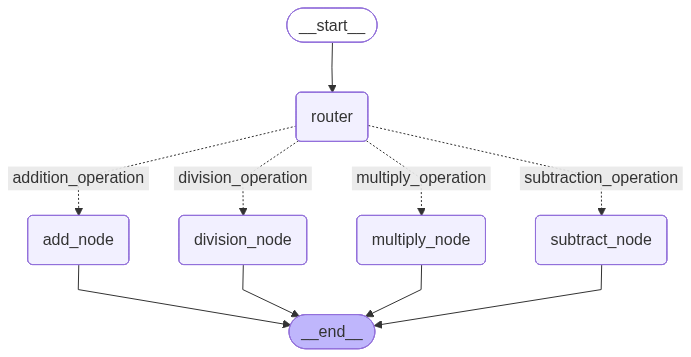

In [20]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result=app.invoke({'number1':15, 'operation':'*', 'number2':10})
result['finalNumber']

150

In [16]:
result=app.invoke({'number1':15, 'operation':'-', 'number2':10})
result['finalNumber']

5

In [21]:
result=app.invoke({'number1':15, 'operation':'/', 'number2':10})
result['finalNumber']

1.5